#### 1.Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

the Descriptive analytics helps in understanding the dataset by summarizing its main features using statistical measures and visualizations.

#### 2.Descriptive Analytics for Numerical Columns

Objective

To compute and analyze basic statistical measures for numerical columns in the dataset.

Steps
1.Load the dataset using Python (pandas).
2.Identify numerical columns such as:
Sales
Quantity
Discount
Profit
3.Calculate statistical measures:
Mean
Median
Mode
Standard Deviation


In [1]:
import pandas as pd

In [117]:
# Load dataset
df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\sales_dataset.csv")
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [118]:
# Display basic statistics
print(df.describe())

           Volume     Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.000000    450.000000         450.000000         450.000000   
mean     5.066667  10453.433333       33812.835556          15.155242   
std      4.231602  18079.904840       50535.074173           4.220602   
min      1.000000    290.000000         400.000000           5.007822   
25%      3.000000    465.000000        2700.000000          13.965063   
50%      4.000000   1450.000000        5700.000000          16.577766   
75%      6.000000  10100.000000       53200.000000          18.114718   
max     31.000000  60100.000000      196400.000000          19.992407   

       Discount Amount  Net Sales Value  
count       450.000000       450.000000  
mean       3346.499424     30466.336131  
std        4509.902963     46358.656624  
min          69.177942       326.974801  
25%         460.459304      2202.208645  
50%         988.933733      4677.788059  
75%        5316.495427     47847.912852  
max   

In [119]:
# Mean
print(df.mean(numeric_only=True))

Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64


In [120]:
# Median
print(df.median(numeric_only=True))

Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64


In [121]:
# Mode
print(df.mode(numeric_only=True))

     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0       3.0      400.0            24300.0           5.007822        69.177942   
1       NaN      450.0                NaN           5.055218        73.025199   
2       NaN      500.0                NaN           5.059801        93.649161   
3       NaN     1300.0                NaN           5.072124        94.682735   
4       NaN     8100.0                NaN           5.084108       102.705757   
..      ...        ...                ...                ...              ...   
445     NaN        NaN                NaN          19.940610     17900.983733   
446     NaN        NaN                NaN          19.965340     21153.498820   
447     NaN        NaN                NaN          19.976879     21496.675367   
448     NaN        NaN                NaN          19.982257     25328.224204   
449     NaN        NaN                NaN          19.992407     25738.022194   

     Net Sales Value  
0   

In [122]:
# Standard Deviation
print(df.std(numeric_only=True))

Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


#### 3. Data Visualization

3.1 Histograms

To understand the distribution of numerical data.

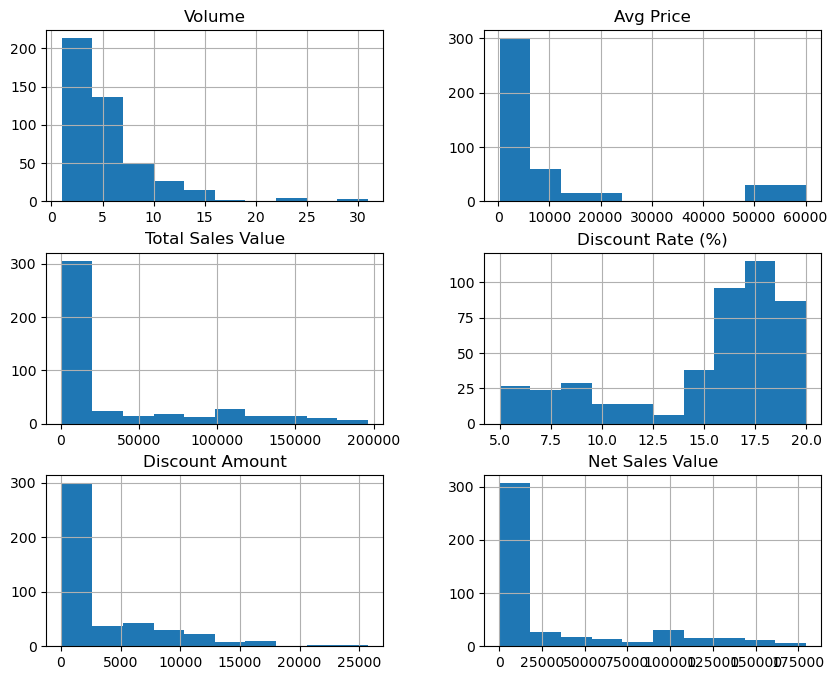

In [123]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

3.2 Boxplots
Objective
To detect outliers and interquartile range (IQR

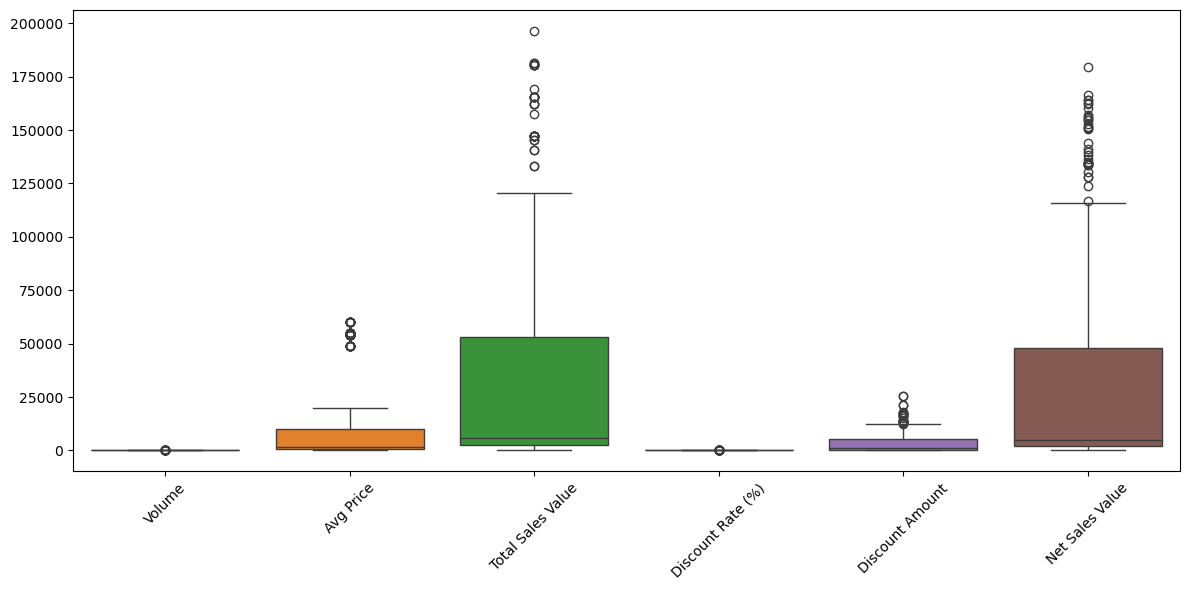

In [124]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


3.3 Bar Chart for Categorical Columns
Objective

To analyze categorical variables.

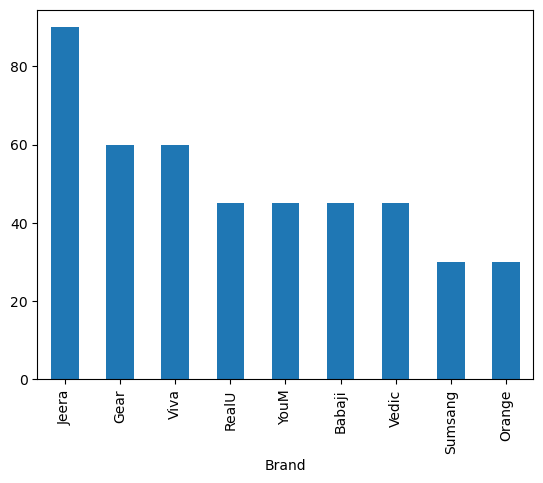

In [125]:
df['Brand'].value_counts().plot(kind='bar')
plt.show()

#### 4. Standardization of Numerical Variables


In [126]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['int64','float64'])

df_scaled = scaler.fit_transform(numeric_cols)

df_scaled = pd.DataFrame(df_scaled, columns=numeric_cols.columns)

print(df_scaled.head())

     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0  2.350029   0.091173           2.925721          -0.830289         3.952816   
1  1.167129  -0.019570           1.330995          -0.852661         1.849014   
2  0.457388   0.312659           1.562775          -1.351631         1.622995   
3  0.220808   0.534146           1.719276          -1.949723         1.113807   
4 -0.488932  -0.130313          -0.188452           0.673739         0.227852   

   Net Sales Value  
0         2.804756  
1         1.271026  
2         1.545675  
3         1.765810  
4        -0.227595  


#### 5. Conversion of Categorical Data into Dummy Variables


In [127]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  Date_02-04-2021  Date_03-04-2021  Date_04-04-2021  \
0    160346.501180            False            False            False   
1     89323.897039            False            False            False   
2    102042.089843            False            False            False   
3    112235.925298            False            False            False   
4     19927.053770            False            False            False   

   Date_05-04-2021  ...  Model_Vedic Cream  Model_Vedic Oil  \
0            False  ...

#### 6. Conclusion

Descriptive analytics helped in understanding dataset patterns.
Histograms and boxplots revealed:
Skewness
Outliers
Bar charts showed category distribution.
Standardization improved data consistency.
One-hot encoding made categorical data usable for ML models.
Final Insight